
# Kagome fRG sanity-check pipeline

This notebook builds a **standard spinful kagome model** using the corrected `channels.py` and `frg_flow.py`, then runs two benchmark interaction points inspired by the PRL phase diagram:

- **FM benchmark:** `U=6, V=0`
- **PI benchmark:** `U=0, V=10`

Target setup:
- no flux
- van Hove filling proxy: `mu = 0`
- `Npatch = 12`

The purpose is simple:

1. verify the corrected longitudinal channel construction in a full end-to-end pipeline  
2. check whether the final leading instability looks **FM-like** for large `U`  
3. check whether it looks **PI-like** for large `V`  

If the second case still does **not** show PI-like structure, the next place to inspect is likely:
- `form_factor.py`
- `kagome_order_diagnosis.py`

---


In [2]:
import sys
from pathlib import Path
from pprint import pprint
import numpy as np
import numpy as np
import matplotlib.pyplot as plt

# Make sure the uploaded modules are importable
sys.path.insert(0, "/mnt/data")

from noninteracting import KagomeNagaosa
from patching import FSPatcher, plot_patchset
from interaction import BareExtendedHubbard
from frg_flow import BareVertexFromInteraction, FRGFlowSolver
import sys
sys.path.insert(0, "/mnt/data")


## 1. Global parameters

You can tune the flow resolution here.

Notes:
- `mu=0` matches the PRL convention for kagome VHF.
- `band_index=1` is the dispersive band crossing `mu=0` inside each 3x3 spin block.
- `Npatch=12` is intentionally small, just for a fast pipeline sanity check.
- For a more reliable final physics check, increase `Npatch`, `nfreq`, and `n_steps`.


In [4]:

# ---------- noninteracting / patching ----------
MODEL_PARAMS = dict(t=1.0, phi=0.0)   # standard kagome = phi=0
MU = 0.0
NPATCH = 24
GRID_SIZE = 320
CONTOUR_MIN_POINTS = 40

# Each spin block is 3x3 inside the full 6x6 spinful Hamiltonian
UP_SLICE = slice(0, 3)
DN_SLICE = slice(3, 6)
LOCAL_BAND_INDEX = 1   # dispersive band crossing mu=0

# ---------- flow ----------
FLOW_KWARGS = dict(
    T_start=40,
    T_stop=0.5,
    n_steps=1000,
    nfreq=30,
    diagnose_every=10,
    temperature_grid="log",
    include_explicit_T_prefactor=True,
    max_relative_update=1,
    min_substep_fraction=0.05,
    channel_divergence_threshold=1e4,
    eigenvalue_threshold=1e4,
    diagnosis_sort_by="abs",
    track_crossed_channel=True,
    diagnosis_Qs = [np.array([0.0, 0.0]), np.array([0.0,  np.pi/np.sqrt(3)]), np.array([ np.pi/2,  np.pi/(2*np.sqrt(3))]), np.array([-np.pi/2,  np.pi/(2*np.sqrt(3))])]
)


## 2. Build the standard spinful kagome model and the two spin patchsets

Patch counts: {'up': 6, 'dn': 6}
mu used for contour (up/dn): 0.0 0.0
gauge method (up/dn): manual_exact_M_hex_6_parallel_transport manual_exact_M_hex_6_parallel_transport

===== exact M6 anchors in centered 1BZ =====
M0: k=[-1.570796 -0.9069  ] | E_up=1.0947644253e-47 | E_dn=1.0947644253e-47
M1: k=[ 0.       -1.813799] | E_up=1.0344233826e-31 | E_dn=1.0344233826e-31
M2: k=[ 1.570796 -0.9069  ] | E_up=1.4997597827e-32 | E_dn=1.4997597827e-32
M3: k=[1.570796 0.9069  ] | E_up=1.0947644253e-47 | E_dn=1.0947644253e-47
M4: k=[0.       1.813799] | E_up=1.0344233826e-31 | E_dn=1.0344233826e-31
M5: k=[-1.570796  0.9069  ] | E_up=1.4997597827e-32 | E_dn=1.4997597827e-32

===== up exact-M6 patches =====
id= 0 | k=[-1.570796 -0.9069  ] | E=1.0947644253e-47 | |vF|=7.747454e-16 | w=[0. 1. 0.]
id= 1 | k=[ 0.       -1.813799] | E=1.0344233826e-31 | |vF|=3.449543e-16 | w=[1. 0. 0.]
id= 2 | k=[ 1.570796 -0.9069  ] | E=1.4997597827e-32 | |vF|=2.255553e-16 | w=[0. 0. 1.]
id= 3 | k=[1.570796 0.9069  ] | E

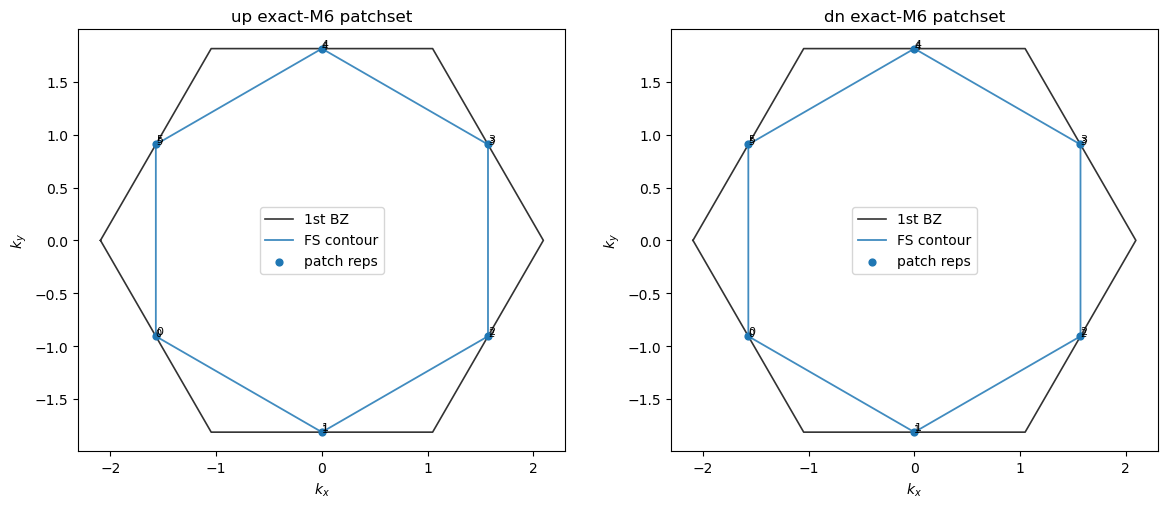

In [10]:
# ============================================================
# Manual exact-M patchsets on standard centered 1BZ hexagon
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from patching import PatchPoint, PatchSet, plot_patchset

model = KagomeNagaosa(MODEL_PARAMS, spin=True, B=None)

# ------------------------------------------------------------
# basic helpers
# ------------------------------------------------------------
def _sector_eig(model, k_cart, orbital_slice, band_index):
    kx, ky = float(k_cart[0]), float(k_cart[1])
    H = np.asarray(model.Hk(kx, ky), dtype=complex)
    Hs = H[orbital_slice, orbital_slice]
    evals, evecs = np.linalg.eigh(Hs)
    u = np.asarray(evecs[:, band_index], dtype=complex)
    u = u / np.linalg.norm(u)
    return float(evals[band_index]), u

def _orbital_weight(u):
    w = np.abs(np.asarray(u, dtype=complex))**2
    return w / np.sum(w)

def _cart_to_red(model, k):
    B = np.column_stack([
        np.asarray(model.b1, dtype=float),
        np.asarray(model.b2, dtype=float),
    ])
    return np.linalg.solve(B, np.asarray(k, dtype=float))

def _finite_diff_velocity(model, k_cart, orbital_slice, band_index, h=1e-6):
    kx, ky = float(k_cart[0]), float(k_cart[1])

    def band_energy(x, y):
        H = np.asarray(model.Hk(x, y), dtype=complex)
        Hs = H[orbital_slice, orbital_slice]
        evals, _ = np.linalg.eigh(Hs)
        return float(evals[band_index])

    vx = (band_energy(kx + h, ky) - band_energy(kx - h, ky)) / (2*h)
    vy = (band_energy(kx, ky + h) - band_energy(kx, ky - h)) / (2*h)
    return np.array([vx, vy], dtype=float)


# ------------------------------------------------------------
# 1BZ geometry
# ------------------------------------------------------------
def hex_bz_vertices(model):
    """
    Standard centered 1BZ hexagon vertices for triangular/kagome reciprocal lattice.

    For reciprocal vectors b1, b2, the Wigner-Seitz 1BZ vertices are:
        ±(2b1-b2)/3, ±(b1+b2)/3, ±(-b1+2b2)/3
    """
    b1 = np.asarray(model.b1, dtype=float)
    b2 = np.asarray(model.b2, dtype=float)

    verts = np.array([
        (2*b1 - b2) / 3.0,
        (b1 + b2) / 3.0,
        (-b1 + 2*b2) / 3.0,
        -(2*b1 - b2) / 3.0,
        -(b1 + b2) / 3.0,
        -(-b1 + 2*b2) / 3.0,
    ], dtype=float)

    ang = np.arctan2(verts[:, 1], verts[:, 0])
    order = np.argsort(ang)
    return verts[order]


def exact_M6_points_1bz(model):
    """
    6 geometric M points on the boundary of the standard centered 1BZ hexagon.
    Each M point is the midpoint of one hexagon edge.
    """
    V = hex_bz_vertices(model)
    M = []

    n = len(V)
    for i in range(n):
        v0 = V[i]
        v1 = V[(i + 1) % n]
        M.append(0.5 * (v0 + v1))

    M = np.asarray(M, dtype=float)

    # keep consistent cyclic order
    ang = np.arctan2(M[:, 1], M[:, 0])
    order = np.argsort(ang)
    return M[order]


def exact_M_hex_loop_points(model, points_per_edge=1):
    """
    Build a manual hex loop from the 6 exact M points on the centered 1BZ.

    points_per_edge = 1  ->  6 patches  (6 exact M points)
    points_per_edge = 2  -> 12 patches
    points_per_edge = 4  -> 24 patches

    Total patch number = 6 * points_per_edge
    """
    if points_per_edge < 1:
        raise ValueError("points_per_edge must be >= 1")

    M6 = exact_M6_points_1bz(model)
    pts = []

    n = len(M6)
    for i in range(n):
        k0 = M6[i]
        k1 = M6[(i + 1) % n]

        # put points_per_edge points on each M-to-M segment:
        # t = 0, 1/p, 2/p, ..., (p-1)/p
        # exclude t=1 to avoid duplicating the next M point
        for m in range(points_per_edge):
            t = m / points_per_edge
            k = (1.0 - t) * k0 + t * k1
            pts.append(k)

    return np.asarray(pts, dtype=float)


def _hex_bz_vertices_for_plot(model):
    return hex_bz_vertices(model)


# ------------------------------------------------------------
# patchset builder
# ------------------------------------------------------------
# ============================================================
# Gauge fixing (parallel transport)
# ============================================================
def smooth_patch_eigvecs(eigvecs):
    """
    Parallel transport gauge fixing along patch loop.
    Make <u_i | u_{i+1}> real positive.
    """
    ulist = [eigvecs[0] / np.linalg.norm(eigvecs[0])]

    for i in range(1, len(eigvecs)):
        u_prev = ulist[-1]
        u = eigvecs[i] / np.linalg.norm(eigvecs[i])

        overlap = np.vdot(u_prev, u)
        phase = np.angle(overlap)

        u = u * np.exp(-1j * phase)
        ulist.append(u)

    return ulist


# ============================================================
# patchset builder WITH gauge fixing
# ============================================================
def build_exactM_patchset(model, orbital_slice, band_index, points_per_edge=1):
    K = exact_M_hex_loop_points(model, points_per_edge=points_per_edge)
    bz_vertices = _hex_bz_vertices_for_plot(model)

    # ------------------------------------------------------------
    # step 1: compute raw eigenvectors
    # ------------------------------------------------------------
    raw_eigvecs = []
    energies = []
    velocities = []

    for k in K:
        e, u = _sector_eig(model, k, orbital_slice, band_index)
        vF = _finite_diff_velocity(model, k, orbital_slice, band_index)

        raw_eigvecs.append(u)
        energies.append(e)
        velocities.append(vF)

    # ------------------------------------------------------------
    # step 2: gauge fixing (KEY STEP)
    # ------------------------------------------------------------
    fixed_eigvecs = smooth_patch_eigvecs(raw_eigvecs)

    # ------------------------------------------------------------
    # step 3: build PatchPoint
    # ------------------------------------------------------------
    patches = []
    for pid, (k, e, vF, u) in enumerate(zip(K, energies, velocities, fixed_eigvecs)):
        patches.append(
            PatchPoint(
                patch_id=pid,
                k_cart=np.asarray(k, dtype=float),
                k_red=_cart_to_red(model, k),
                energy=e,
                vF=vF,
                vF_norm=float(np.linalg.norm(vF)),
                eigvec=u,
                orbital_weight=_orbital_weight(u),
            )
        )

    npatch = len(K)

    return PatchSet(
        mu=0.0,
        mu_used_for_contour=0.0,
        band_index=int(band_index),
        filling=np.nan,
        patches=patches,
        fs_contour_k=np.asarray(K, dtype=float),
        bz_vertices=np.asarray(bz_vertices, dtype=float),
        b1=np.asarray(model.b1, dtype=float),
        b2=np.asarray(model.b2, dtype=float),
        gauge_method=f"manual_exact_M_hex_{npatch}_parallel_transport",
        gauge_loop_phase=0.0,
    )

# ------------------------------------------------------------
# choose patch density here
# ------------------------------------------------------------
POINTS_PER_EDGE = 1   # 1->6, 2->12, 4->24
NPATCH = 6 * POINTS_PER_EDGE

patchsets = {
    "up": build_exactM_patchset(
        model, UP_SLICE, LOCAL_BAND_INDEX, points_per_edge=POINTS_PER_EDGE
    ),
    "dn": build_exactM_patchset(
        model, DN_SLICE, LOCAL_BAND_INDEX, points_per_edge=POINTS_PER_EDGE
    ),
}


# ------------------------------------------------------------
# print info
# ------------------------------------------------------------
print("Patch counts:", {k: v.Npatch for k, v in patchsets.items()})
print("mu used for contour (up/dn):", patchsets["up"].mu_used_for_contour, patchsets["dn"].mu_used_for_contour)
print("gauge method (up/dn):", patchsets["up"].gauge_method, patchsets["dn"].gauge_method)

print("\n===== exact M6 anchors in centered 1BZ =====")
M6 = exact_M6_points_1bz(model)
for i, k in enumerate(M6):
    e_up, _ = _sector_eig(model, k, UP_SLICE, LOCAL_BAND_INDEX)
    e_dn, _ = _sector_eig(model, k, DN_SLICE, LOCAL_BAND_INDEX)
    print(
        f"M{i}: k={np.round(k, 6)} | "
        f"E_up={e_up:.10e} | E_dn={e_dn:.10e}"
    )

for spin in ["up", "dn"]:
    print(f"\n===== {spin} exact-M{NPATCH} patches =====")
    for p in patchsets[spin].patches:
        print(
            f"id={p.patch_id:2d} | "
            f"k={np.round(p.k_cart, 6)} | "
            f"E={p.energy:.10e} | "
            f"|vF|={p.vF_norm:.6e} | "
            f"w={np.round(p.orbital_weight, 6)}"
        )


# ------------------------------------------------------------
# neighbor distance sanity check
# ------------------------------------------------------------
for spin in ["up", "dn"]:
    ks = np.array([p.k_cart for p in patchsets[spin].patches], dtype=float)
    d = np.linalg.norm(np.roll(ks, -1, axis=0) - ks, axis=1)
    print(f"\n===== {spin} neighbor distances =====")
    print(np.round(d, 8))


# ------------------------------------------------------------
# plot
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, spin in zip(axes, ["up", "dn"]):
    plot_patchset(patchsets[spin], ax=ax, show_contour=True, show_velocity=False, show_bz=True)
    ks = np.array([p.k_cart for p in patchsets[spin].patches], dtype=float)

    for i, k in enumerate(ks):
        ax.text(k[0], k[1], str(i), fontsize=8, ha="left", va="bottom")

    ax.set_title(f"{spin} exact-M{NPATCH} patchset")

plt.tight_layout()
plt.show()

## 3. Helpers for running a benchmark interaction point  Debug FRG Solver

In [12]:
from frg_flow import FRGFlowSolver

_old_step = FRGFlowSolver.step
_old_run = FRGFlowSolver.run

def _debug_step(self, T_old, dT):
    print(f"[DEBUG] entering step: T_old={T_old:.8f}, dT={dT:.8e}")
    try:
        rec = _old_step(self, T_old, dT)
        print(
            f"[DEBUG] leaving step: "
            f"T_new={getattr(rec, 'temperature', float(T_old + dT)):.8f}, "
            f"rhs_norm={getattr(rec, 'rhs_norm', None)}, "
            f"channel_norm={getattr(rec, 'channel_norm', None)}, "
            f"accepted_substeps={getattr(rec, 'accepted_substeps', None)}, "
            f"max_rel_update={getattr(rec, 'max_rel_update', None)}"
        )
        return rec
    except Exception as e:
        print(f"[DEBUG] exception in step:")
        print(f"        T_old = {T_old:.8f}")
        print(f"        dT    = {dT:.8e}")
        print(f"        T_new = {T_old + dT:.8f}")
        raise

def _debug_run(self):
    # print("[DEBUG] temperature path:")
    # for i, T in enumerate(self.temperature_path):
    #     print(f"  i={i:03d}, T={float(T):.8f}")
    return _old_run(self)

FRGFlowSolver.step = _debug_step
FRGFlowSolver.run = _debug_run

def build_solver(model, patchsets, U, V, flow_kwargs=None):
    flow_kwargs = {} if flow_kwargs is None else dict(flow_kwargs)
    interaction = BareExtendedHubbard.from_kagome_model(model, U=U, V=V)
    bare_gamma = BareVertexFromInteraction(interaction, patchsets)
    solver = FRGFlowSolver(
        patchsets=patchsets,
        bare_gamma=bare_gamma,
        **flow_kwargs,
    )
    return interaction, bare_gamma, solver


def summarize_history(history):
    rows = []
    for rec in history:
        rows.append({
            "step": rec.step_index,
            "T": rec.temperature,
            "channel_norm": rec.channel_norm,
            "rhs_norm": rec.rhs_norm,
            "leading_channel": rec.leading_channel_name,
            "leading_order": rec.leading_order_label,
            "leading_abs_eval": rec.leading_eigenvalue_abs,
            "instability": rec.instability,
            "reason": rec.instability_reason,
        })
    return rows


def pretty_print_final_record(history):
    rec = history[-1]
    print("===== Final record =====")
    pprint(rec.summary_dict())
    return rec


def plot_history(history, title):
    steps = [h.step_index for h in history]
    Ts = [h.temperature for h in history]
    evals = [np.nan if h.leading_eigenvalue_abs is None else h.leading_eigenvalue_abs for h in history]
    norms = [h.channel_norm for h in history]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(steps, evals, marker="o")
    axes[0].set_xlabel("step")
    axes[0].set_ylabel("leading |eigenvalue|")
    axes[0].set_title(f"{title}: leading eigenvalue")

    axes[1].plot(steps, norms, marker="o")
    axes[1].set_xlabel("step")
    axes[1].set_ylabel("channel norm")
    axes[1].set_title(f"{title}: channel norm")

    plt.tight_layout()
    plt.show()


def run_case(case_name, U, V, flow_kwargs=None):
    print(f"\n===== Running case: {case_name} (U={U}, V={V}) =====")
    interaction, bare_gamma, solver = build_solver(
        model=model,
        patchsets=patchsets,
        U=U,
        V=V,
        flow_kwargs=flow_kwargs if flow_kwargs is not None else FLOW_KWARGS,
    )
    history = solver.run()
    print(f"history length = {len(history)}")
    print(f"instability record = {None if solver.instability_record is None else solver.instability_record.step_index}")
    final_rec = pretty_print_final_record(history)
    plot_history(history, case_name)
    return {
        "case_name": case_name,
        "U": U,
        "V": V,
        "interaction": interaction,
        "solver": solver,
        "history": history,
        "final_record": final_rec,
    }



## 4. FM benchmark: `U=6, V=0`

Expectation from the PRL benchmark at van Hove filling:
- dominant onsite interaction should favor **ferromagnetism (FM)**.



===== Running case: FM benchmark (U=6.0, V=0.0) =====
[DEBUG] entering step: T_old=40.00000000, dT=-1.75072272e-01
[DEBUG] leaving step: T_new=39.82492773, rhs_norm=0.02235048295163479, channel_norm=0.003912949820640226, accepted_substeps=1, max_rel_update=0.0006521583034400376
[DEBUG] entering step: T_old=39.82492773, dT=-1.74306014e-01
[DEBUG] leaving step: T_new=39.65062171, rhs_norm=0.022591555092229428, channel_norm=0.007850793739865976, accepted_substeps=1, max_rel_update=0.0006563073198709585
[DEBUG] entering step: T_old=39.65062171, dT=-1.73543110e-01
[DEBUG] leaving step: T_new=39.47707860, rhs_norm=0.022835423660596158, channel_norm=0.01181372418695124, accepted_substeps=1, max_rel_update=0.0006604884078475441
[DEBUG] entering step: T_old=39.47707860, dT=-1.72783546e-01
[DEBUG] leaving step: T_new=39.30429506, rhs_norm=0.023082124009373005, channel_norm=0.015801935414124033, accepted_substeps=1, max_rel_update=0.0006647018711954653
[DEBUG] entering step: T_old=39.30429506, d

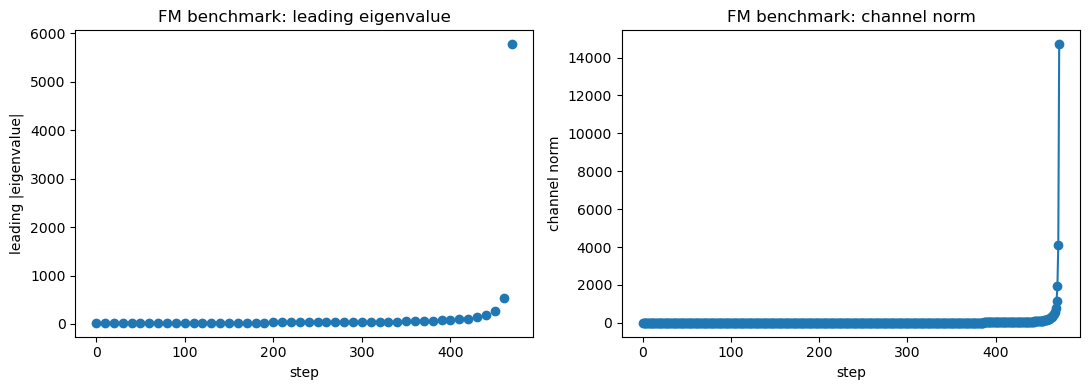

In [15]:

fm_result = run_case("FM benchmark", U=6.0, V=.0, flow_kwargs=FLOW_KWARGS)


===== Final-state mother-channel diagnosis across all Q =====

===== Q[0] = [0. 0.] =====
pp_mother_sz0            |eig|max = 48510.02
ph_mother_longitudinal   |eig|max = 157.29093
--> leading mother channel at this Q: pp_mother_sz0  (|eig|max = 48510.02)

===== Q[1] = [0.         1.81379936] =====
pp_mother_sz0            |eig|max = 1.7997117e-31
ph_mother_longitudinal   |eig|max = 8.9985455e-32
--> leading mother channel at this Q: pp_mother_sz0  (|eig|max = 1.7997117e-31)

===== Q[2] = [1.57079633 0.90689968] =====
pp_mother_sz0            |eig|max = 1.4212792e-30
ph_mother_longitudinal   |eig|max = 7.1064172e-31
--> leading mother channel at this Q: pp_mother_sz0  (|eig|max = 1.4212792e-30)

===== Q[3] = [-1.57079633  0.90689968] =====
pp_mother_sz0            |eig|max = 1.4212792e-30
ph_mother_longitudinal   |eig|max = 7.1064178e-31
--> leading mother channel at this Q: pp_mother_sz0  (|eig|max = 1.4212792e-30)
[{'Q_index': 0, 'Q_vec': array([0., 0.]), 'pp_mother_sz0': 48510.02018

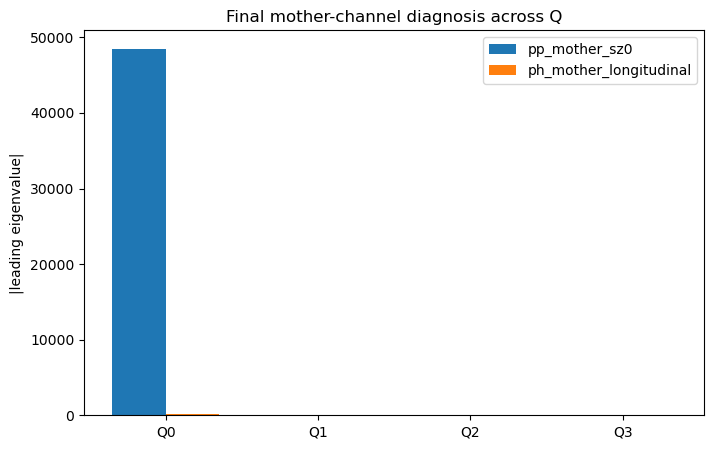


==== pp_mother_sz0 ====
Q = [0. 0.]
|eig|max = 48510.02018324391
vec.real = [-4.33651543e-05 -3.40423349e-04 -4.32000458e-01  5.61858903e-05
  4.41068163e-04  5.59719681e-01  4.33651543e-05  3.40423349e-04
  4.32000458e-01 -5.61858903e-05 -4.41068163e-04 -5.59719681e-01]
vec.abs  = [1.87338618e-04 5.77672878e-03 4.32000458e-01 2.42724538e-04
 7.48459574e-03 5.59719681e-01 1.87338618e-04 5.77672878e-03
 4.32000458e-01 2.42724538e-04 7.48459574e-03 5.59719681e-01]

==== pp_mother_sz0 ====
Q = [0. 0.]
second |eig|max = 48510.0201832439
vec.real = [-4.32039120e-01  2.62760443e-16 -5.08157456e-31  5.59769773e-01
  9.47972259e-17  7.87797859e-31  4.32039120e-01  7.31659907e-17
  4.47401249e-31 -5.59769773e-01 -9.47972259e-17 -7.87797859e-31]
vec.abs  = [4.32039120e-01 2.62760443e-16 5.08157456e-31 5.59769773e-01
 9.47972259e-17 7.87797859e-31 4.32039120e-01 7.31659907e-17
 4.47401249e-31 5.59769773e-01 9.47972259e-17 7.87797859e-31]

==== ph_mother_longitudinal ====
Q = [0. 0.]
|eig|max = 1

In [17]:
import numpy as np
import matplotlib.pyplot as plt

Qs_to_check = FLOW_KWARGS["diagnosis_Qs"]
# 如果你想继续测试 Q -> Q+G 不变性，再手动加 reciprocal vector
# Qs_to_check = FLOW_KWARGS["diagnosis_Qs"] + 5*np.array([np.pi, np.pi/np.sqrt(3)]) + np.array([0,2*np.pi/np.sqrt(3)])

solver = fm_result["solver"]

mother_channels = [
    "pp_mother_sz0",
    "ph_mother_longitudinal",
]

print("===== Final-state mother-channel diagnosis across all Q =====")
Q_summary = []

for i, Q in enumerate(Qs_to_check):
    Q = np.asarray(Q, dtype=float)
    mothers = solver.build_mother_kernel_dict(Q)

    print(f"\n===== Q[{i}] = {Q} =====")
    row = {
        "Q_index": i,
        "Q_vec": Q,
    }

    vals_dict = {}
    for name in mother_channels:
        k = mothers[name]
        vals, vecs = k.eig(sort_by="abs")
        eigmax = abs(vals[0])
        vals_dict[name] = eigmax
        row[name] = float(eigmax)
        print(f"{name:24s} |eig|max = {eigmax:.8g}")

    lead_name = max(vals_dict, key=vals_dict.get)
    row["leading_geometry"] = lead_name
    row["leading_value"] = vals_dict[lead_name]
    Q_summary.append(row)

    print(f"--> leading mother channel at this Q: {lead_name}  (|eig|max = {vals_dict[lead_name]:.8g})")

print(Q_summary)
labels = [f"Q{i}" for i in range(len(Q_summary))]
x = np.arange(len(labels))
width = 0.35

pp_vals = [row["pp_mother_sz0"] for row in Q_summary]
ph_vals = [row["ph_mother_longitudinal"] for row in Q_summary]

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, pp_vals, width, label="pp_mother_sz0")
plt.bar(x + width/2, ph_vals, width, label="ph_mother_longitudinal")

plt.xticks(x, labels)
plt.ylabel("|leading eigenvalue|")
plt.title("Final mother-channel diagnosis across Q")
plt.legend()
plt.show()

# ----------------------------------------
Q = np.array([0.0, 0.0])
mothers = solver.build_mother_kernel_dict(Q)

for name in ["pp_mother_sz0", "ph_mother_longitudinal"]:
    k = mothers[name]
    vals, vecs = k.eig(sort_by="abs")
    print(f"\n==== {name} ====")
    print("Q =", k.Q)
    print("|eig|max =", abs(vals[0]))
    print("vec.real =", np.real(vecs[:, 0]))
    print("vec.abs  =", np.abs(vecs[:, 0]))
    print(f"\n==== {name} ====")
    print("Q =", k.Q)
    print("second |eig|max =", abs(vals[1]))
    print("vec.real =", np.real(vecs[:, 1]))
    print("vec.abs  =", np.abs(vecs[:, 1]))


## 5. sBO benchmark: `U=6, V=6`

<!-- - dominant nearest-neighbor repulsion should favor **Pomeranchuk instability (PI)** with d-wave character. -->



===== Running case: sBO benchmark (U=6.0, V=6.0) =====
[DEBUG] entering step: T_old=40.00000000, dT=-1.75072272e-01
[DEBUG] leaving step: T_new=39.82492773, rhs_norm=1.0504726987268356, channel_norm=0.18390864157009068, accepted_substeps=1, max_rel_update=0.01532572013084089
[DEBUG] entering step: T_old=39.82492773, dT=-1.74306014e-01
[DEBUG] leaving step: T_new=39.65062171, rhs_norm=1.0968827694813974, channel_norm=0.3751019049940637, accepted_substeps=1, max_rel_update=0.015932771951997757
[DEBUG] entering step: T_old=39.65062171, dT=-1.73543110e-01
[DEBUG] leaving step: T_new=39.47707860, rhs_norm=1.1464628129421905, channel_norm=0.5740626273956998, accepted_substeps=1, max_rel_update=0.016580060200136342
[DEBUG] entering step: T_old=39.47707860, dT=-1.72783546e-01
[DEBUG] leaving step: T_new=39.30429506, rhs_norm=1.1995013618044286, channel_norm=0.7813167256846996, accepted_substeps=1, max_rel_update=0.017271174857416652
[DEBUG] entering step: T_old=39.30429506, dT=-1.72027305e-01

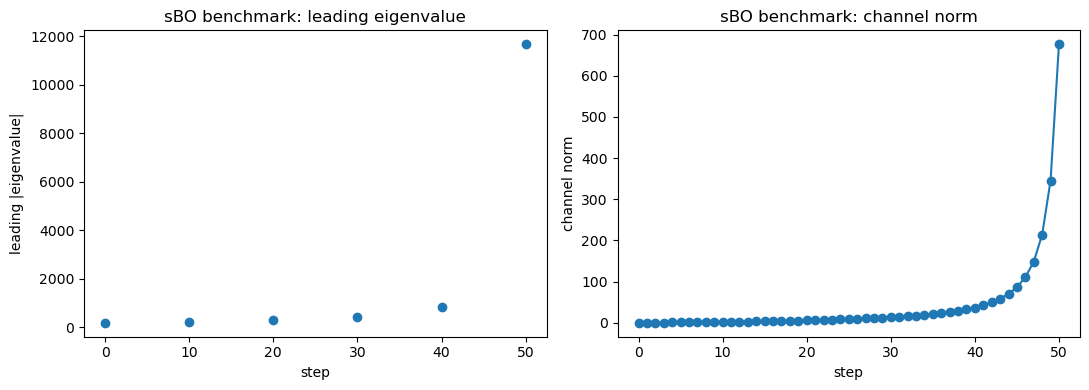

In [5]:

sBO_result = run_case("sBO benchmark", U=6.0, V=6.0, flow_kwargs=FLOW_KWARGS)


===== Final-state mother-channel diagnosis across all Q =====

===== Q[0] = [0. 0.] =====
pp_mother_sz0            |eig|max = 2042.4609
ph_mother_longitudinal   |eig|max = 11668.401
--> leading mother channel at this Q: ph_mother_longitudinal  (|eig|max = 11668.401)

===== Q[1] = [0.         1.81379936] =====
pp_mother_sz0            |eig|max = 2049.0436
ph_mother_longitudinal   |eig|max = 2079.4112
--> leading mother channel at this Q: ph_mother_longitudinal  (|eig|max = 2079.4112)

===== Q[2] = [1.57079633 0.90689968] =====
pp_mother_sz0            |eig|max = 2056.0065
ph_mother_longitudinal   |eig|max = 2087.0694
--> leading mother channel at this Q: ph_mother_longitudinal  (|eig|max = 2087.0694)

===== Q[3] = [-1.57079633  0.90689968] =====
pp_mother_sz0            |eig|max = 2054.2105
ph_mother_longitudinal   |eig|max = 2087.5312
--> leading mother channel at this Q: ph_mother_longitudinal  (|eig|max = 2087.5312)
[{'Q_index': 0, 'Q_vec': array([0., 0.]), 'pp_mother_sz0': 2042.4609

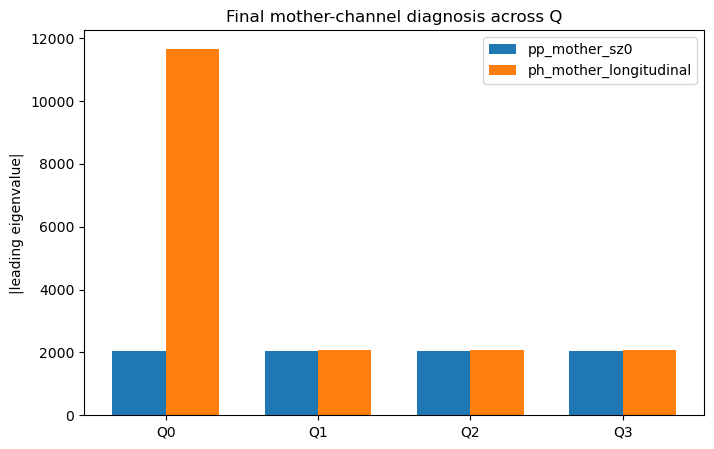


==== pp_mother_sz0 ====
Q = [0. 0.]
|eig|max = 2042.4609000688256
vec.real = [-1.56170481e-01  2.33558027e-03  4.65848368e-04 -2.14839451e-03
  2.97823206e-01 -3.03526838e-03 -2.57550962e-04  2.80686264e-03
 -3.70093481e-01  1.22852214e-03  1.15179734e-03 -1.46279234e-03
 -1.56136572e-01  1.89347659e-03 -6.70250061e-04 -1.96589188e-03
  2.97703543e-01 -2.71195387e-03  3.08669174e-04  2.65884914e-03
 -3.69967331e-01  2.23214751e-03  5.27281804e-04 -9.89526426e-04
  1.56170481e-01 -2.33558027e-03 -4.65848368e-04  2.14839451e-03
 -2.97823206e-01  3.03526838e-03  2.57550962e-04 -2.80686264e-03
  3.70093481e-01 -1.22852214e-03 -1.15179734e-03  1.46279234e-03
  1.56136572e-01 -1.89347659e-03  6.70250061e-04  1.96589188e-03
 -2.97703543e-01  2.71195387e-03 -3.08669174e-04 -2.65884914e-03
  3.69967331e-01 -2.23214751e-03 -5.27281804e-04  9.89526426e-04]
vec.abs  = [1.56170481e-01 2.33558027e-03 4.65848368e-04 2.14839451e-03
 2.97823206e-01 3.03526838e-03 2.57550962e-04 2.80686264e-03
 3.70093

In [6]:
import numpy as np
import matplotlib.pyplot as plt

Qs_to_check = FLOW_KWARGS["diagnosis_Qs"]
# 如果你想继续测试 Q -> Q+G 不变性，再手动加 reciprocal vector
# Qs_to_check = FLOW_KWARGS["diagnosis_Qs"] + 5*np.array([np.pi, np.pi/np.sqrt(3)]) + np.array([0,2*np.pi/np.sqrt(3)])

solver = sBO_result["solver"]

mother_channels = [
    "pp_mother_sz0",
    "ph_mother_longitudinal",
]

print("===== Final-state mother-channel diagnosis across all Q =====")
Q_summary = []

for i, Q in enumerate(Qs_to_check):
    Q = np.asarray(Q, dtype=float)
    mothers = solver.build_mother_kernel_dict(Q)

    print(f"\n===== Q[{i}] = {Q} =====")
    row = {
        "Q_index": i,
        "Q_vec": Q,
    }

    vals_dict = {}
    for name in mother_channels:
        k = mothers[name]
        vals, vecs = k.eig(sort_by="abs")
        eigmax = abs(vals[0])
        vals_dict[name] = eigmax
        row[name] = float(eigmax)
        print(f"{name:24s} |eig|max = {eigmax:.8g}")

    lead_name = max(vals_dict, key=vals_dict.get)
    row["leading_geometry"] = lead_name
    row["leading_value"] = vals_dict[lead_name]
    Q_summary.append(row)

    print(f"--> leading mother channel at this Q: {lead_name}  (|eig|max = {vals_dict[lead_name]:.8g})")

print(Q_summary)
labels = [f"Q{i}" for i in range(len(Q_summary))]
x = np.arange(len(labels))
width = 0.35

pp_vals = [row["pp_mother_sz0"] for row in Q_summary]
ph_vals = [row["ph_mother_longitudinal"] for row in Q_summary]

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, pp_vals, width, label="pp_mother_sz0")
plt.bar(x + width/2, ph_vals, width, label="ph_mother_longitudinal")

plt.xticks(x, labels)
plt.ylabel("|leading eigenvalue|")
plt.title("Final mother-channel diagnosis across Q")
plt.legend()
plt.show()

# ----------------------------------------
Q = np.array([0.0, 0.0])
mothers = solver.build_mother_kernel_dict(Q)

for name in ["pp_mother_sz0", "ph_mother_longitudinal"]:
    k = mothers[name]
    vals, vecs = k.eig(sort_by="abs")
    print(f"\n==== {name} ====")
    print("Q =", k.Q)
    print("|eig|max =", abs(vals[0]))
    print("vec.real =", np.real(vecs[:, 0]))
    print("vec.abs  =", np.abs(vecs[:, 0]))
    print(f"\n==== {name} ====")
    print("Q =", k.Q)
    print("second |eig|max =", abs(vals[1]))
    print("vec.real =", np.real(vecs[:, 1]))
    print("vec.abs  =", np.abs(vecs[:, 1]))

# Save & Load

In [14]:
# # ============================================================
# # SAVE fm_result and sBO_result
# # ============================================================
#
# import os
# import gzip
#
# try:
#     import cloudpickle as cpkl
#     _PICKLER_NAME = "cloudpickle"
# except Exception:
#     import pickle as cpkl
#     _PICKLER_NAME = "pickle"
#
# SAVE_PATH = "saved_frg_results.pkl.gz"
#
# payload = {
#     "fm_result": fm_result,
#     "sBO_result": sBO_result,
# }
#
# with gzip.open(SAVE_PATH, "wb") as f:
#     cpkl.dump(payload, f)
#
# print(f"[SAVE] done with {_PICKLER_NAME}")
# print(f"[SAVE] file = {os.path.abspath(SAVE_PATH)}")
# print(f"[SAVE] keys = {list(payload.keys())}")

[SAVE] done with pickle
[SAVE] file = C:\Users\28547\Documents\GitHub\functional-RG-Kagome-\saved_frg_results.pkl.gz
[SAVE] keys = ['fm_result', 'sBO_result']


In [7]:
# ============================================================
# LOAD fm_result and sBO_result
# ============================================================

import os
import gzip

try:
    import cloudpickle as cpkl
    _PICKLER_NAME = "cloudpickle"
except Exception:
    import pickle as cpkl
    _PICKLER_NAME = "pickle"

SAVE_PATH = "saved_frg_results.pkl.gz"

if not os.path.exists(SAVE_PATH):
    raise FileNotFoundError(f"Cannot find saved file: {os.path.abspath(SAVE_PATH)}")

with gzip.open(SAVE_PATH, "rb") as f:
    loaded_payload = cpkl.load(f)

fm_result = loaded_payload["fm_result"]
sBO_result = loaded_payload["sBO_result"]

print(f"[LOAD] loaded with {_PICKLER_NAME}")
print(f"[LOAD] keys = {list(loaded_payload.keys())}")
print(f"[LOAD] fm_result type = {type(fm_result)}")
print(f"[LOAD] sBO_result type = {type(sBO_result)}")

# ============================================================
# SANITY CHECK after load
# ============================================================

for name, obj in [("fm_result", fm_result), ("sBO_result", sBO_result)]:
    print(f"\n===== {name} =====")
    if isinstance(obj, dict):
        print("dict keys:", list(obj.keys()))
        if "solver" in obj:
            solver = obj["solver"]
            print("solver type:", type(solver))
            print("T_start, T_stop =", getattr(solver, "T_start", None), getattr(solver, "T_stop", None))
            print("diagnosis_Qs =", getattr(solver, "diagnosis_Qs", None))
    else:
        print("type:", type(obj))

[LOAD] loaded with pickle
[LOAD] keys = ['fm_result', 'sBO_result']
[LOAD] fm_result type = <class 'dict'>
[LOAD] sBO_result type = <class 'dict'>

===== fm_result =====
dict keys: ['case_name', 'U', 'V', 'interaction', 'solver', 'history', 'final_record']
solver type: <class 'frg_flow.FRGFlowSolver'>
T_start, T_stop = 30.0 0.5
diagnosis_Qs = [array([0., 0.]), array([1.57079633, 2.72069905]), array([0.        , 1.81379936]), array([1.57079633, 0.90689968])]

===== sBO_result =====
dict keys: ['case_name', 'U', 'V', 'interaction', 'solver', 'history', 'final_record']
solver type: <class 'frg_flow.FRGFlowSolver'>
T_start, T_stop = 30.0 0.5
diagnosis_Qs = [array([0., 0.]), array([1.57079633, 2.72069905]), array([0.        , 1.81379936]), array([1.57079633, 0.90689968])]


# Debug